# Acoustic Wave Torus Geometric Deep Learning Framework
This notebook contains the complete implementation, combining all modules into a single executable environment.


In [ ]:
!pip install torch numpy scipy matplotlib h5py scikit-learn


## Geometry Module


In [1]:
import torch
import numpy as np

class TorusGeometry:
    def __init__(self, R: float = 1.0, r: float = 0.3):
        r"""
        Differential geometry of a 2D Torus.
        Coordinates: (theta, phi)
        theta \in [0, 2pi) - Poloidal angle (around the tube)
        phi \in [0, 2pi)   - Toroidal angle (around the main axis)
        
        Metric g:
        ds^2 = r^2 d\theta^2 + (R + r \cos\theta)^2 d\phi^2
        """
        self.R = R
        self.r = r

    def get_metric_elements(self, theta: torch.Tensor):
        r"""
        Returns the non-zero components of the metric tensor: g_{\theta\theta} and g_{\phi\phi}
        """
        g_tt = torch.full_like(theta, self.r**2)
        g_pp = (self.R + self.r * torch.cos(theta))**2
        return g_tt, g_pp

    def get_inverse_metric_elements(self, theta: torch.Tensor):
        r"""
        Returns g^{\theta\theta} and g^{\phi\phi}
        """
        g_tt, g_pp = self.get_metric_elements(theta)
        return 1.0 / g_tt, 1.0 / g_pp

    def get_sqrt_det_g(self, theta: torch.Tensor):
        r"""
        Returns \sqrt{|g|} = r(R + r \cos\theta)
        """
        return self.r * (self.R + self.r * torch.cos(theta))


def compute_gradient(f, dtheta: float, dphi: float):
    r"""
    Computes \nabla f = [ \partial_\theta f, \partial_\phi f ] 
    using 4th-order central differences with periodic boundaries.
    f shape: (Batch, Channels, N_theta, N_phi)
    """
    # 4th order: (-f_{i+2} + 8f_{i+1} - 8f_{i-1} + f_{i-2}) / 12h
    # Pad circularly
    f_pad_theta = torch.nn.functional.pad(f, (0, 0, 2, 2), mode='circular')
    df_dtheta = (-f_pad_theta[:, :, 4:, :] + 8*f_pad_theta[:, :, 3:-1, :] - 
                 8*f_pad_theta[:, :, 1:-3, :] + f_pad_theta[:, :, :-4, :]) / (12 * dtheta)
    
    f_pad_phi = torch.nn.functional.pad(f, (2, 2, 0, 0), mode='circular')
    df_dphi = (-f_pad_phi[:, :, :, 4:] + 8*f_pad_phi[:, :, :, 3:-1] - 
               8*f_pad_phi[:, :, :, 1:-3] + f_pad_phi[:, :, :, :-4]) / (12 * dphi)
               
    return df_dtheta, df_dphi


def compute_laplace_beltrami(f: torch.Tensor, geometry: TorusGeometry, dtheta: float, dphi: float):
    r"""
    Computes \Delta_M f = \frac{1}{\sqrt{|g|}} \partial_i (\sqrt{|g|} g^{ij} \partial_j f)
    f shape: (Batch, Channels, N_theta, N_phi)
    """
    device = f.device
    N_theta = f.shape[2]
    
    # 1D theta grid matching spatial resolution
    theta_1d = torch.linspace(0, 2*np.pi, N_theta + 1, device=device)[:-1]
    theta_grid = theta_1d.view(1, 1, N_theta, 1) # Expand shapes for broadcasting
    
    # Differential geometry terms
    sqrt_g = geometry.get_sqrt_det_g(theta_grid)
    g_inv_tt, g_inv_pp = geometry.get_inverse_metric_elements(theta_grid)
    
    # 1. Gradient: \partial_j f
    df_dtheta, df_dphi = compute_gradient(f, dtheta, dphi)
    
    # 2. Multiply by \sqrt{|g|} g^{ij}
    V_theta = sqrt_g * g_inv_tt * df_dtheta
    V_phi   = sqrt_g * g_inv_pp * df_dphi
    
    # 3. Divergence: \partial_i V^i
    dV_theta_dtheta, _ = compute_gradient(V_theta, dtheta, dphi)
    _, dV_phi_dphi = compute_gradient(V_phi, dtheta, dphi)
    
    # 4. Multiply by 1/\sqrt{|g|}
    laplacian = (1.0 / sqrt_g) * (dV_theta_dtheta + dV_phi_dphi)
    
    return laplacian


## Simulator Module


In [2]:
class TorusAcousticSimulator:
    def __init__(self, R=3.0, r=1.0, c=343.0, N_theta=128, N_phi=128, dt=0.001):
        self.solver = TorusSpectralSolver(R, r, c, N_theta, N_phi, CFL=0.1)
        self.dt = dt if dt else self.solver.dt
        self.solver.dt = self.dt
    def generate_gaussian_source(self, t, t0=0.05, sigma_t=0.01, theta0=np.pi, phi0=np.pi, sigma_s=0.5, amplitude=None, device='cpu'):
        if amplitude is None: amplitude = torch.tensor([1.0], device=device)
        return self.solver.generate_ricker_pulse(t, t0, sigma_t, theta0, phi0, sigma_s, amplitude, device)
    def simulate(self, num_steps=500, source_generator_fn=None, device='cpu', record_every=10):
        return self.solver.simulate(num_steps, source_generator_fn, device, record_every)
    def save_to_h5(self, P, S, filename):
        save_simulation_to_h5(P, S, filename, self.solver.R, self.solver.r, self.solver.dt, self.solver.N_theta, self.solver.N_phi)

import h5py
import torch
import numpy as np
from typing import Callable, Optional, Tuple

class TorusWaveSolverRK4:
    def __init__(self, R: float = 1.0, r: float = 0.3, c: float = 1.0, 
                 N_theta: int = 256, N_phi: int = 256, CFL: float = 0.5):
        """
        High-fidelity 4th-Order Runge-Kutta acoustic wave solver on the Torus.
        """
        self.geom = TorusGeometry(R, r)
        self.c = c
        self.N_theta = N_theta
        self.N_phi = N_phi
        
        self.dtheta = 2 * np.pi / N_theta
        self.dphi = 2 * np.pi / N_phi
        
        # Strictest grid size occurs at the inner equator (theta = pi)
        # where g_{\phi\phi} = (R - r)^2, so physical distance dphi_phys = (R-r)*dphi
        min_dx = min(r * self.dtheta, (R - r) * self.dphi)
        
        # Time step governed by Courant-Friedrichs-Lewy condition
        self.dt = CFL * min_dx / c
        print(f"Initialized TorusSolver: Grid {N_theta}x{N_phi}. Required dt: {self.dt:.6f}")

    def generate_ricker_pulse(self, t: float, t0: float, sigma_t: float, 
                             theta0: float, phi0: float, sigma_s: float, 
                             amplitude: torch.Tensor, device: torch.device):
        """
        A zero-mean Ricker Wavelet (Mexican Hat) source pulse.
        """
        theta_1d = torch.linspace(0, 2*np.pi, self.N_theta + 1, device=device)[:-1]
        phi_1d = torch.linspace(0, 2*np.pi, self.N_phi + 1, device=device)[:-1]
        
        theta_grid, phi_grid = torch.meshgrid(theta_1d, phi_1d, indexing='ij')
        
        dtheta_dist = (theta_grid - theta0 + np.pi) % (2*np.pi) - np.pi
        dphi_dist = (phi_grid - phi0 + np.pi) % (2*np.pi) - np.pi
        
        # Physical squared distance
        r_sq = (self.geom.r * dtheta_dist)**2 + ((self.geom.R + self.geom.r * np.cos(theta0)) * dphi_dist)**2
        
        # Ricker Wavelet: (1 - r^2/sigma^2) * exp(-r^2/(2*sigma^2))
        r_sq_over_sigma_sq = r_sq / (sigma_s ** 2)
        spatial = (2.0 - r_sq_over_sigma_sq) * torch.exp(-r_sq / (2 * sigma_s ** 2))
        
        # Subtract mean to ensure zero-mean (Mexican Hat filter)
        spatial = spatial - spatial.mean()
        
        temporal = np.exp(-(t - t0)**2 / (2 * sigma_t**2))
        
        S = spatial * temporal
        S = S.unsqueeze(-1) * amplitude
        S = S.unsqueeze(0).permute(0, 3, 1, 2)
        return S

    def _rk4_step(self, P: torch.Tensor, Q: torch.Tensor, S: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Wave equation as first order system:
        dP/dt = Q
        dQ/dt = c^2 Delta_M P + S
        """
        def dP_dt(q):
            return q
            
        def dQ_dt(p, s):
            LB = compute_laplace_beltrami(p, self.geom, self.dtheta, self.dphi)
            return self.c**2 * LB + s

        k1_P = dP_dt(Q)
        k1_Q = dQ_dt(P, S)

        P2 = P + 0.5 * self.dt * k1_P
        Q2 = Q + 0.5 * self.dt * k1_Q
        k2_P = dP_dt(Q2)
        k2_Q = dQ_dt(P2, S)

        P3 = P + 0.5 * self.dt * k2_P
        Q3 = Q + 0.5 * self.dt * k2_Q
        k3_P = dP_dt(Q3)
        k3_Q = dQ_dt(P3, S)

        P4 = P + self.dt * k3_P
        Q4 = Q + self.dt * k3_Q
        k4_P = dP_dt(Q4)
        k4_Q = dQ_dt(P4, S)

        P_new = P + (self.dt / 6.0) * (k1_P + 2*k2_P + 2*k3_P + k4_P)
        Q_new = Q + (self.dt / 6.0) * (k1_Q + 2*k2_Q + 2*k3_Q + k4_Q)

        return P_new, Q_new

    def simulate(self, num_steps: int, source_fn: Optional[Callable], 
                 device: torch.device, record_every: int = 10, channels: int = 1):
        
        P = torch.zeros((1, channels, self.N_theta, self.N_phi), device=device)
        Q = torch.zeros_like(P)
        
        history_P = []
        history_S = []
        
        t = 0.0
        for step in range(num_steps):
            if source_fn:
                S = source_fn(t, device)
            else:
                S = torch.zeros_like(P)
                
            P, Q = self._rk4_step(P, Q, S)
            t += self.dt
            
            if step % record_every == 0:
                history_P.append(P.clone().cpu())
                history_S.append(S.clone().cpu())
                
                if step % (num_steps//10) == 0:
                    print(f"Simulating progress: {100*step/num_steps:.1f}% (t={t:.4f}s)")
                    
                    # Watch for divergence blow-up
                    if not torch.isfinite(P).all() or P.abs().max() > 1e6:
                        print("WARNING: Numerical instability detected!")
                        break

        # Stack to (Batch, Time, Channels, H, W)
        return torch.stack(history_P, dim=1), torch.stack(history_S, dim=1)

class TorusSpectralSolver:
    def __init__(self, R: float = 3.0, r: float = 1.0, c: float = 343.0, 
                 N_theta: int = 256, N_phi: int = 256, CFL: float = 0.1):
        """
        Implementation of the Fourier Pseudospectral method for acoustic waves on a torus.
        As described in acoustic-spectral.md
        """
        self.R = R
        self.r = r
        self.c = c
        self.N_theta = N_theta
        self.N_phi = N_phi
        
        self.d_theta = 2 * np.pi / N_theta
        self.d_phi = 2 * np.pi / N_phi
        
        # CFL Condition: dt = CFL * min_dx / c
        min_dx = min(r * self.d_theta, (R - r) * self.d_phi)
        self.dt = CFL * min_dx / c
        
        # Wavenumbers for spectral differentiation
        # k = [0, 1, ..., N/2-1, -N/2, ..., -1]
        self.k_theta = torch.fft.fftfreq(N_theta).to(torch.float32) * N_theta
        self.k_phi = torch.fft.fftfreq(N_phi).to(torch.float32) * N_phi
        
        self.K_THETA, self.K_PHI = torch.meshgrid(self.k_theta, self.k_phi, indexing='ij')

        # Static Geometric Terms (Physical Space)
        theta_grid = torch.linspace(0, 2*np.pi, N_theta + 1)[:-1]
        phi_grid = torch.linspace(0, 2*np.pi, N_phi + 1)[:-1]
        THETA, _ = torch.meshgrid(theta_grid, phi_grid, indexing='ij')
        
        self.THETA = THETA
        self.g_inv_tt = 1.0 / (r**2)
        self.g_inv_pp = 1.0 / (R + r * torch.cos(THETA))**2
        self.gamma_term = -torch.sin(THETA) / (r * (R + r * torch.cos(THETA)))
        self.sqrt_g = r * (R + r * torch.cos(THETA))

    def generate_ricker_pulse(self, t: float, t0: float, sigma_t: float, 
                             theta0: float, phi0: float, sigma_s: float, 
                             amplitude: torch.Tensor, device: torch.device):
        """
        Generate a zero-mean Ricker Wavelet (Mexican Hat) source pulse in 2D.
        """
        theta_1d = torch.linspace(0, 2*np.pi, self.N_theta + 1, device=device)[:-1]
        phi_1d = torch.linspace(0, 2*np.pi, self.N_phi + 1, device=device)[:-1]
        
        theta_grid, phi_grid = torch.meshgrid(theta_1d, phi_1d, indexing='ij')
        
        dtheta_dist = (theta_grid - theta0 + np.pi) % (2*np.pi) - np.pi
        dphi_dist = (phi_grid - phi0 + np.pi) % (2*np.pi) - np.pi
        
        # Physical squared distance
        r_sq = (self.r * dtheta_dist)**2 + ((self.R + self.r * np.cos(theta0)) * dphi_dist)**2
        
        r_sq_over_sigma_sq = r_sq / (sigma_s ** 2)
        spatial = (2.0 - r_sq_over_sigma_sq) * torch.exp(-r_sq / (2 * sigma_s ** 2))
        spatial = spatial - spatial.mean()
        
        temporal = np.exp(-(t - t0)**2 / (2 * sigma_t**2))
        
        # S base shape: (N_theta, N_phi)
        S_base = spatial * temporal
        
        # Expand based on amplitude (C, H, W)
        # amplitude shape: (C,)
        S = S_base.unsqueeze(0) * amplitude.view(-1, 1, 1)
        return S # (C, H, W)

    def compute_laplace_beltrami(self, P: torch.Tensor) -> torch.Tensor:
        """
        Computes the Laplacian in spectral space.
        """
        device = P.device
        # Move precomputed tensors to the correct device if needed
        self.K_THETA = self.K_THETA.to(device)
        self.K_PHI = self.K_PHI.to(device)
        self.g_inv_pp = self.g_inv_pp.to(device)
        self.gamma_term = self.gamma_term.to(device)
        self.sqrt_g = self.sqrt_g.to(device)

        # Forward FFT
        P_hat = torch.fft.fft2(P)
        
        # First derivative w.r.t theta: F^-1 [ i * k_theta * P_hat ]
        dP_dtheta_hat = 1j * self.K_THETA * P_hat
        dP_dtheta = torch.real(torch.fft.ifft2(dP_dtheta_hat))
        
        # Second derivative w.r.t theta: F^-1 [ -k_theta^2 * P_hat ]
        d2P_dtheta2_hat = -(self.K_THETA**2) * P_hat
        d2P_dtheta2 = torch.real(torch.fft.ifft2(d2P_dtheta2_hat))
        
        # Second derivative w.r.t phi: F^-1 [ -k_phi^2 * P_hat ]
        d2P_dphi2_hat = -(self.K_PHI**2) * P_hat
        d2P_dphi2 = torch.real(torch.fft.ifft2(d2P_dphi2_hat))
        
        # Assemble Laplacian in physical space
        # LB = (1/r^2) * d2P/dtheta^2 + gamma * dP/dtheta + g^pp * d2P/dphi^2
        # Note: self.g_inv_tt is 1/r^2
        laplace = (self.g_inv_tt * d2P_dtheta2) + \
                  (self.gamma_term * dP_dtheta) + \
                  (self.g_inv_pp * d2P_dphi2)
                  
        return laplace

    def simulate(self, num_steps: int, source_fn: Optional[Callable], 
                 device: torch.device, record_every: int = 10, channels: int = 3):
        """
        Explicit Leapfrog Time-Stepping as per acoustic-spectral.md
        """
        P_curr = torch.zeros((channels, self.N_theta, self.N_phi), device=device)
        P_prev = torch.zeros_like(P_curr)
        
        history_P = []
        history_S = []
        t = 0.0
        
        for step in range(num_steps):
            S_curr = source_fn(t, device) if source_fn else torch.zeros_like(P_curr)
            
            # Evaluate Laplacian
            laplacian = self.compute_laplace_beltrami(P_curr)
            
            # Acceleration: c^2 * (Laplacian + S)
            accel = (self.c**2) * (laplacian + S_curr)
            
            # Leapfrog: P_next = 2*P_curr - P_prev + dt^2 * acceleration
            P_next = 2 * P_curr - P_prev + (self.dt**2) * accel
            
            # Update state
            P_prev = P_curr
            P_curr = P_next
            t += self.dt
            
            if step % record_every == 0:
                history_P.append(P_curr.clone().cpu())
                history_S.append(S_curr.clone().cpu())
                
                if step % (max(1, num_steps//10)) == 0:
                    print(f"Spectral Sim: {100*step/num_steps:.1f}% (t={t:.4f}s)")
                    if not torch.isfinite(P_curr).all():
                        print("ERROR: Divergence in spectral solver!")
                        break

        # Return (Batch=1, Time, Channels, H, W) to match the expected deep learning dataset shape
        P_stack = torch.stack(history_P, dim=0).unsqueeze(0)
        S_stack = torch.stack(history_S, dim=0).unsqueeze(0)
        return P_stack, S_stack


def save_simulation_to_h5(P, S, filename, R, r, dt, N_theta, N_phi):
    with h5py.File(filename, 'w') as f:
        # Move Channels to end for storage: (B, T, C, H, W) -> (B, T, H, W, C)
        P_save = P.permute(0, 1, 3, 4, 2).numpy()
        S_save = S.permute(0, 1, 3, 4, 2).numpy()
        f.create_dataset('pressure', data=P_save, compression="gzip")
        f.create_dataset('source', data=S_save, compression="gzip")
        f.attrs['R'] = R
        f.attrs['r'] = r
        f.attrs['dt'] = dt
        f.attrs['N_theta'] = N_theta
        f.attrs['N_phi'] = N_phi
    print(f"Dataset successfully saved to {filename}")


## Dataset Generation for Kaggle
Generates multi-sample wave propagation sequences mapped on a downsampled 128x128 Torus grid.


In [5]:
NUM_EXAMPLES = 20
SEQ_LEN = 512
N_THETA = 128
N_PHI = 128

def generate_dataset(num_examples=10, sequence_length=128):
    all_P = []
    all_S = []
    
    # Initialize high-fidelity spectral solver
    # Using CFL=0.1 for maximum stability in spectral domain
    simulator = TorusSpectralSolver(R=1.5, r=0.5, c=1.0, N_theta=N_THETA, N_phi=N_PHI, CFL=0.1)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Generating high-fidelity spectral dataset on: {device}")

    for i in range(num_examples):
        # Randomize impulse characteristics
        t0 = np.random.uniform(0.01, 0.05)
        theta0 = np.random.uniform(0, 2*np.pi)
        phi0 = np.random.uniform(0, 2*np.pi)
        
        # Spectral source function (returns (C, H, W))
        source_fn = lambda t, dev: simulator.generate_ricker_pulse(
            t, t0=t0, sigma_t=0.01, theta0=theta0, phi0=phi0, sigma_s=0.1, 
            amplitude=torch.tensor([1.0, 1.0, 1.0], device=dev), device=dev
        )

        # Simulate: returns (B=1, Time, Channels, H, W)
        P_seq, S_seq = simulator.simulate(num_steps=sequence_length, source_fn=source_fn, device=device, record_every=1)
        
        all_P.append(P_seq[0]) # (Time, Channels, H, W)
        all_S.append(S_seq[0])
        if i % 2 == 0:
            print(f"Generated sequence {i+1}/{num_examples}")

    # Stack to (Batch, Time, Channels, H, W)
    P_tensor = torch.stack(all_P, dim=0)
    S_tensor = torch.stack(all_S, dim=0)

    h5_path = 'training_data.h5'
    save_simulation_to_h5(P_tensor, S_tensor, h5_path, 
                          simulator.R, simulator.r, simulator.dt, 
                          simulator.N_theta, simulator.N_phi)
    return h5_path

dataset_path = generate_dataset(num_examples=NUM_EXAMPLES, sequence_length=SEQ_LEN)


Generating high-fidelity spectral dataset on: cuda
Spectral Sim: 0.0% (t=0.0025s)
Spectral Sim: 10.0% (t=0.1276s)
Spectral Sim: 19.9% (t=0.2528s)
Spectral Sim: 29.9% (t=0.3780s)
Spectral Sim: 39.8% (t=0.5031s)
Spectral Sim: 49.8% (t=0.6283s)
Spectral Sim: 59.8% (t=0.7535s)
Spectral Sim: 69.7% (t=0.8787s)
Spectral Sim: 79.7% (t=1.0038s)
Spectral Sim: 89.6% (t=1.1290s)
Spectral Sim: 99.6% (t=1.2542s)
Generated sequence 1/20
Spectral Sim: 0.0% (t=0.0025s)
Spectral Sim: 10.0% (t=0.1276s)
Spectral Sim: 19.9% (t=0.2528s)
Spectral Sim: 29.9% (t=0.3780s)
Spectral Sim: 39.8% (t=0.5031s)
Spectral Sim: 49.8% (t=0.6283s)
Spectral Sim: 59.8% (t=0.7535s)
Spectral Sim: 69.7% (t=0.8787s)
Spectral Sim: 79.7% (t=1.0038s)
Spectral Sim: 89.6% (t=1.1290s)
Spectral Sim: 99.6% (t=1.2542s)
Spectral Sim: 0.0% (t=0.0025s)
Spectral Sim: 10.0% (t=0.1276s)
Spectral Sim: 19.9% (t=0.2528s)
Spectral Sim: 29.9% (t=0.3780s)
Spectral Sim: 39.8% (t=0.5031s)
Spectral Sim: 49.8% (t=0.6283s)
Spectral Sim: 59.8% (t=0.7535s)


## Dataset Verification
Visualize the compiled sequences to guarantee proper physical dynamics prior to DL training.


Dataset successfully loaded shape: (20, 512, 128, 128, 3) (Batch, Time, H, W, Channels)


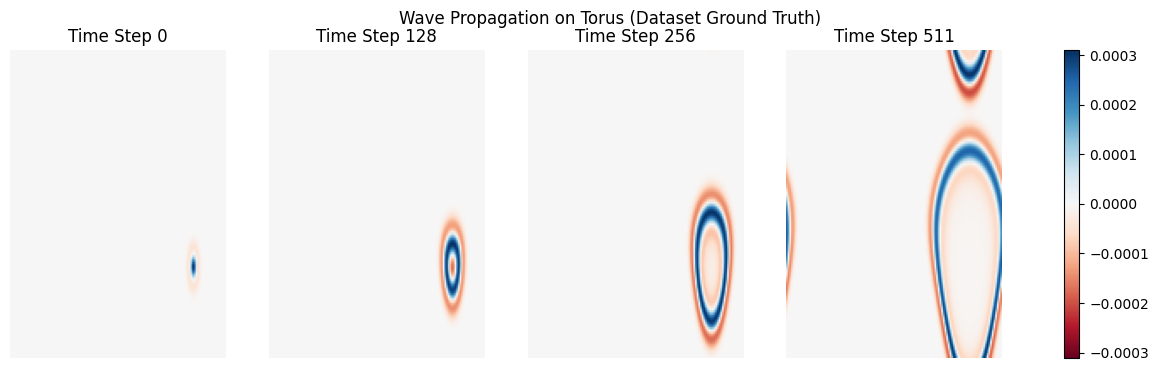

In [6]:
import matplotlib.pyplot as plt

def verify_dataset(filepath):
    with h5py.File(filepath, 'r') as f:
        P = f['pressure'][:]
        S = f['source'][:]
        
    print(f"Dataset successfully loaded shape: {P.shape} (Batch, Time, H, W, Channels)")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    time_indices = [0, P.shape[1]//4, P.shape[1]//2, P.shape[1]-1]
    
    for i, t_idx in enumerate(time_indices):
        # Indexing: batch=0, time=t_idx, H, W, channel=0
        field = P[1, t_idx, :, :, 0]
        
        # Using a normalized color map centered around 0 to highlight the peaks vs troughs
        vmax = np.max(np.abs(field)) + 1e-9
        vmin = -vmax
        
        im = axes[i].imshow(field, cmap='RdBu', vmin=vmin, vmax=vmax, aspect='auto')
        axes[i].set_title(f"Time Step {t_idx}")
        axes[i].axis('off')
        
    fig.colorbar(im, ax=axes.ravel().tolist())
    plt.suptitle("Wave Propagation on Torus (Dataset Ground Truth)")
    plt.show()

# verify_dataset(dataset_path)

verify_dataset("training_data.h5")

## Detailed HDF5 Dataset Exploration
To fully understand the structure and properties of the generated dataset, the following block explores the dataset keys, attributes, and plots time-domain traces and maximum amplitude (energy) maps.

--- Exploring training_data.h5 ---
Attributes:
  N_phi: 128
  N_theta: 128
  R: 1.5
  dt: 0.002454369260617026
  r: 0.5

Datasets:
  pressure: shape=(20, 512, 128, 128, 3), dtype=float32, chunking=(3, 64, 16, 16, 1), compression=gzip
  source: shape=(20, 512, 128, 128, 3), dtype=float32, chunking=(3, 64, 16, 16, 1), compression=gzip


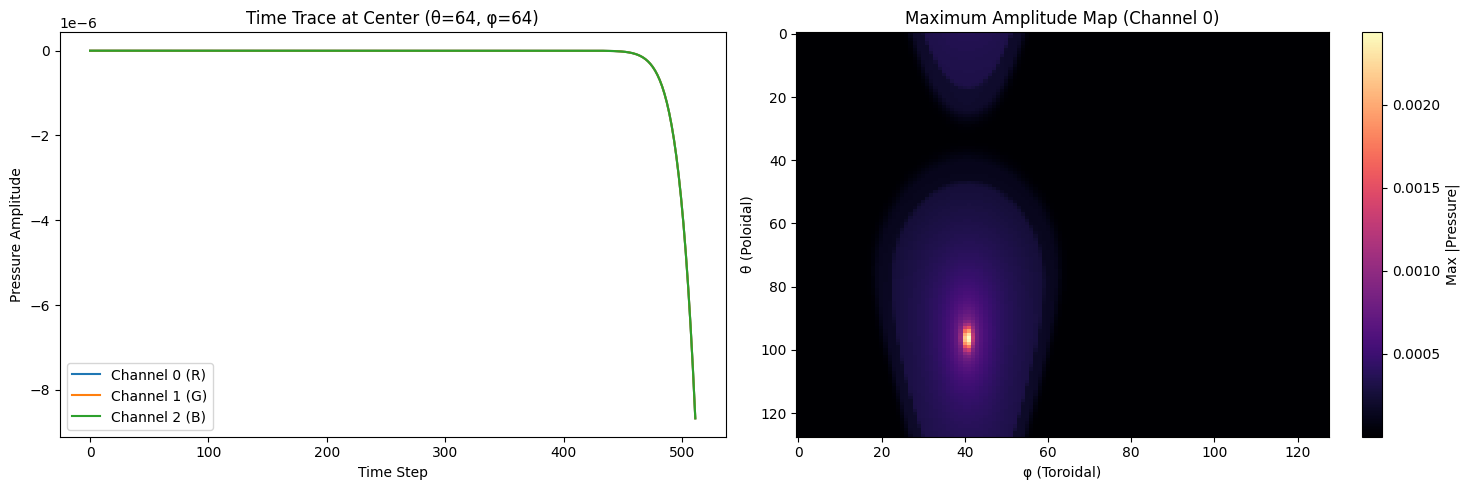

In [7]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

def explore_hdf5(filepath):
    print(f"--- Exploring {filepath} ---")
    with h5py.File(filepath, 'r') as f:
        # Print attributes
        print("Attributes:")
        for k, v in f.attrs.items():
            print(f"  {k}: {v}")
            
        print("\nDatasets:")
        for key in f.keys():
            ds = f[key]
            print(f"  {key}: shape={ds.shape}, dtype={ds.dtype}, chunking={ds.chunks}, compression={ds.compression}")
            
        # Load Pressure
        P = f['pressure'][:]
        
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # 1. Time-domain trace at the center for different channels
        H, W = P.shape[2], P.shape[3]
        center_trace = P[0, :, H//2, W//2, :] # (Time, Channels)
        
        axes[0].plot(center_trace)
        axes[0].set_title(f"Time Trace at Center (θ={H//2}, φ={W//2})")
        axes[0].set_xlabel("Time Step")
        axes[0].set_ylabel("Pressure Amplitude")
        if center_trace.shape[1] == 3:
            axes[0].legend(["Channel 0 (R)", "Channel 1 (G)", "Channel 2 (B)"])
            
        # 2. Maximum Amplitude Map (Energy Map) for Channel 0
        max_amp = np.max(np.abs(P[50, :, :, :, 0]), axis=0)
        im = axes[1].imshow(max_amp, cmap='magma', aspect='auto')
        axes[1].set_title("Maximum Amplitude Map (Channel 0)")
        axes[1].set_xlabel("φ (Toroidal)")
        axes[1].set_ylabel("θ (Poloidal)")
        fig.colorbar(im, ax=axes[1], label="Max |Pressure|")
        
        plt.tight_layout()
        plt.show()

# Assuming `dataset_path` holds the path to the current h5 file
explore_hdf5("training_data.h5")


## Autoregressive Deep Learning Models (Grokking)
Transitioning from Physics-Informed models to data-driven discovery architectures capable of learning the exact PDE.

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def forward(self, x):
        batchsize = x.shape[0]
        # Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft2(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        
        # Upper modes
        out_ft[:, :, :self.modes1, :self.modes2] = \
            torch.einsum("bixy,ioxy->boxy", x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
            
        # Lower modes
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            torch.einsum("bixy,ioxy->boxy", x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        # Return to physical space
        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class FNO2d(nn.Module):
    def __init__(self, modes=12, width=32, in_channels=4, out_channels=1):
        super(FNO2d, self).__init__()
        self.modes1 = modes
        self.modes2 = modes
        self.width = width
        self.fc0 = nn.Linear(in_channels, self.width)
        
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
        
        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, out_channels)

    def forward(self, x):
        # x is (B, C, H, W)
        x = x.permute(0, 2, 3, 1) # to (B, H, W, C)
        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2) # to (B, W, H, W) for convolutions
        
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1 + x2)
        
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1 + x2)
        
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1 + x2)
        
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = F.gelu(x1 + x2)
        
        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)
        x = x.permute(0, 3, 1, 2)
        return x


In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels
        
        # We MUST use circular padding for periodic boundaries
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding=1, padding_mode='circular', bias=False),
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding=1, padding_mode='circular', bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels, in_channels // 2)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        # Use circular padding even for size mismatch padding conceptually
        # Although interpolation should prevent strong mismatches.
        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2], mode='circular')
        
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        # Circular padding for output conv
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class PeriodicUNet(nn.Module):
    """
    Conventional UNet architecture strongly conditioned to Periodic Manifolds.
    By setting padding_mode='circular', the convolution kernels inherently warp
    across the left/right and top/bottom edges of the state tensor, natively simulating
    the Torus topology.
    """
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(PeriodicUNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        
        logits = self.outc(x)
        return logits


In [10]:
import torch
import numpy as np
import h5py
from torch.utils.data import Dataset, DataLoader
import os

class TorusWaveDataset(Dataset):
    """
    NOMAD Dataset for Acoustic Waves on a Torus.
    Loads simulation data from HDF5 files and prepares them for training.
    
    Tensor Shaping: (Batch, Time, Channels, Theta, Phi) -> outputs overlapping sequences.
    Normalization: Z-score standardization (retains stats for denormalization).
    """
    def __init__(self, h5_path, seq_len=4, transform=True):
        if not os.path.exists(h5_path):
            raise FileNotFoundError(f"Simulation data not found at {h5_path}")
            
        with h5py.File(h5_path, 'r') as f:
            self.P = torch.from_numpy(f['pressure'][:]).permute(0, 1, 4, 2, 3)
            self.S = torch.from_numpy(f['source'][:]).permute(0, 1, 4, 2, 3)
            self.R = f.attrs['R']
            self.r = f.attrs['r']
            self.N_theta = f.attrs['N_theta']
            self.N_phi = f.attrs['N_phi']
            
        self.seq_len = seq_len
        self.num_rollouts = self.P.shape[0]
        self.time_steps = self.P.shape[1]
        self.valid_starts_per_rollout = self.time_steps - self.seq_len
        
        self.transform = transform
        if self.transform:
            self._compute_stats()
            self._normalize()

        # Precompute the geometric metric channel
        # Metric g = r(R + r * cos(theta))
        theta_grid = torch.linspace(0, 2*np.pi, self.N_theta + 1)[:-1]
        phi_grid = torch.linspace(0, 2*np.pi, self.N_phi + 1)[:-1]
        THETA, _ = torch.meshgrid(theta_grid, phi_grid, indexing='ij')
        
        metric = self.r * (self.R + self.r * torch.cos(THETA))
        # Normalize metric approximately to [0, 1] range to help neural networks
        m_min = self.r * (self.R - self.r)
        m_max = self.r * (self.R + self.r)
        metric_norm = (metric - m_min) / (m_max - m_min)
        
        # metric_norm: (1, 1, H, W). We'll expand it during getitem
        self.metric_embed = metric_norm.unsqueeze(0).unsqueeze(0).to(torch.float32)

    def _compute_stats(self):
        """Calculates mean and std for Z-score normalization."""
        self.p_mean = self.P.mean()
        self.p_std = self.P.std()
        self.s_mean = self.S.mean()
        self.s_std = self.S.std()
        
        self.p_std = torch.clamp(self.p_std, min=1e-8)
        self.s_std = torch.clamp(self.s_std, min=1e-8)

    def _normalize(self):
        """Applies Z-score standardization."""
        self.P = (self.P - self.p_mean) / self.p_std
        self.S = (self.S - self.s_mean) / self.s_std

    def denormalize_p(self, p_tensor):
        return p_tensor * self.p_std + self.p_mean

    def denormalize_s(self, s_tensor):
        return s_tensor * self.s_std + self.s_mean

    def __len__(self):
        return self.num_rollouts * self.valid_starts_per_rollout
        
    def __getitem__(self, idx):
        # Decode the flattened index into (rollout_idx, time_start)
        rollout_idx = idx // self.valid_starts_per_rollout
        t_start = idx % self.valid_starts_per_rollout
        t_end = t_start + self.seq_len
        
        s_seq = self.S[rollout_idx, t_start:t_end]
        p_seq = self.P[rollout_idx, t_start:t_end]
        
        # We append the static geometry metric map along the sequence so the
        # network inherently knows where the curvature compresses/expands waves.
        # Shape: (Seq_len, 1, H, W)
        m_seq = self.metric_embed.expand(self.seq_len, -1, -1, -1)
        
        return s_seq.float(), p_seq.float(), m_seq.float()

def get_dataloader(h5_path, batch_size=16, seq_len=4, shuffle=True):
    dataset = TorusWaveDataset(h5_path, seq_len=seq_len)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

# Test path
path = "training_data.h5"
if os.path.exists(path):
    dataset = TorusWaveDataset(path)
    s, p, m = dataset[0]
    print(f"Loaded S shape: {s.shape}, P shape: {p.shape}, M shape: {m.shape}")
    print(f"P stats - Mean: {dataset.p_mean:.4f}, Std: {dataset.p_std:.4f}")
else:
    print("Test skipped: .h5 file not found.")


Loaded S shape: torch.Size([4, 3, 128, 128]), P shape: torch.Size([4, 3, 128, 128]), M shape: torch.Size([4, 1, 128, 128])
P stats - Mean: 0.0000, Std: 0.0001


In [20]:
import torch
import numpy as np
import h5py
import os
import argparse
from tqdm import tqdm


def generate_multi_rollout_dataset(filename, num_rollouts=50, steps_per_rollout=500, record_every=10, R=3.0, r=1.0, N_theta=64, N_phi=64):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Generating dataset on {device}...")
    
    # We use a lower resolution (64x64) by default to keep dataset size manageable for training iterations,
    # but still capturing the essential dynamics.
    simulator = TorusAcousticSimulator(R=R, r=r, N_theta=N_theta, N_phi=N_phi)
    
    P_list = []
    S_list = []
    
    for i in tqdm(range(num_rollouts), desc="Simulating Rollouts"):
        # Randomize source location and time
        t0 = np.random.uniform(0.01, 0.1)
        theta0 = np.random.uniform(0, 2*np.pi)
        phi0 = np.random.uniform(0, 2*np.pi)
        sigma_s = np.random.uniform(0.3, 0.8)
        
        def random_source_fn(t, dev):
            return simulator.generate_ricker_pulse(
            t, t0=t0, sigma_t=0.01, theta0=theta0, phi0=phi0, sigma_s=0.1, 
            amplitude=torch.tensor([1.0, 1.0, 1.0], device=dev), device=dev
        )
            
        P_seq, S_seq = simulator.simulate(num_steps=steps_per_rollout, source_generator_fn=random_source_fn, device=device, record_every=record_every)
        P_list.append(P_seq)
        S_list.append(S_seq)
        
    P_all = torch.cat(P_list, dim=0) # (num_rollouts, Time, C, H, W)
    S_all = torch.cat(S_list, dim=0) # (num_rollouts, Time, C, H, W)
    
    # os.makedirs(os.path.dirname(filename), exist_ok=True)
    save_simulation_to_h5(P_all, S_all, filename, R, r, simulator.dt, N_theta, N_phi)


generate_multi_rollout_dataset("torus_simulation_data.h5", num_rollouts=50, steps_per_rollout=512, 
                               N_theta=64, N_phi=64)


Generating dataset on cuda...


Simulating Rollouts:   0%|          | 0/50 [00:00<?, ?it/s]


AttributeError: 'TorusAcousticSimulator' object has no attribute 'generate_ricker_pulse'

Dataset successfully loaded shape: (50, 52, 128, 128, 3) (Batch, Time, H, W, Channels)


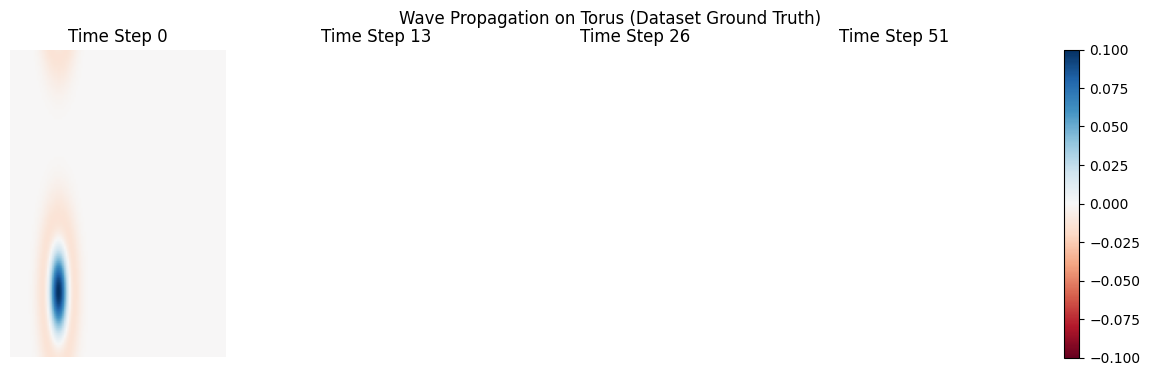

In [17]:
import matplotlib.pyplot as plt

def verify_dataset(filepath):
    with h5py.File(filepath, 'r') as f:
        P = f['pressure'][:]
        S = f['source'][:]
        
    print(f"Dataset successfully loaded shape: {P.shape} (Batch, Time, H, W, Channels)")
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    time_indices = [0, P.shape[1]//4, P.shape[1]//2, P.shape[1]-1]
    
    for i, t_idx in enumerate(time_indices):
        # Indexing: batch=0, time=t_idx, H, W, channel=0
        field = P[1, t_idx, :, :, 0]
        
        # Using a normalized color map centered around 0 to highlight the peaks vs troughs
        vmax = np.max(np.abs(field)) + 1e-9
        vmin = -vmax
        
        im = axes[i].imshow(field, cmap='RdBu', vmin=vmin, vmax=vmax, aspect='auto')
        axes[i].set_title(f"Time Step {t_idx}")
        axes[i].axis('off')
        
    fig.colorbar(im, ax=axes.ravel().tolist())
    plt.suptitle("Wave Propagation on Torus (Dataset Ground Truth)")
    plt.show()

# verify_dataset(dataset_path)

verify_dataset("torus_simulation_data.h5")

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

class DataDrivenTrainer:
    """
    Autoregressive Multi-Step Trainer for Data-Driven PDE discovery.
    Calculates cumulative loss over a rollout window to force the model to capture
    long-term physical dynamics rather than memorizing single-step lazy transitions.
    """
    def __init__(self, model, lr=1e-4, weight_decay=1e-5):
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model = model.to(self.device)
        self.optimizer = optim.AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        self.criterion = nn.MSELoss()

    def train_epoch(self, dataloader, teacher_forcing_ratio=0.0):
        self.model.train()
        total_loss = 0.0

        for s_seq, p_seq, m_seq in dataloader:
            s_seq = s_seq.to(self.device)
            p_seq = p_seq.to(self.device)
            m_seq = m_seq.to(self.device)

            seq_len = p_seq.shape[1]
            if seq_len < 3:
                continue

            # Initial inputs (requires 2 history frames to encode velocity for wave PDE)
            # Shapes: (Batch, Channels, H, W) where Channels=1 usually.
            p_prev = p_seq[:, 0]
            p_curr = p_seq[:, 1]
            
            # Static metric embed (same across time)
            m_static = m_seq[:, 0]

            batch_loss = 0.0

            # Autoregressive Rollout
            for t in range(2, seq_len):
                s_curr = s_seq[:, t-1] # Source applied at t-1 dictates change leading to t
                
                # Model input: [P(t-1), P(t-2), S(t-1), M] -> predicts P(t)
                x_in = torch.cat([p_curr, p_prev, s_curr, m_static], dim=1)
                
                p_next_pred = self.model(x_in)
                p_next_target = p_seq[:, t]
                
                # Accumulate loss
                batch_loss += self.criterion(p_next_pred, p_next_target)
                
                # Roll state forward
                p_prev = p_curr
                
                # Teacher forcing? Sometime we use ground truth to stabilize early training
                use_teacher = torch.rand(1).item() < teacher_forcing_ratio
                p_curr = p_next_target if use_teacher else p_next_pred

            # Average loss over the rollout steps so it doesn't artificially inflate gradients
            batch_loss = batch_loss / (seq_len - 2)

            self.optimizer.zero_grad()
            batch_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()

            total_loss += batch_loss.item()

        return total_loss / len(dataloader)

    def evaluate(self, dataloader):
        self.model.eval()
        total_loss = 0.0
        with torch.no_grad():
            for s_seq, p_seq, m_seq in dataloader:
                s_seq = s_seq.to(self.device)
                p_seq = p_seq.to(self.device)
                m_seq = m_seq.to(self.device)

                seq_len = p_seq.shape[1]
                if seq_len < 3:
                    continue

                p_prev = p_seq[:, 0]
                p_curr = p_seq[:, 1]
                m_static = m_seq[:, 0]

                batch_loss = 0.0

                for t in range(2, seq_len):
                    s_curr = s_seq[:, t-1]
                    
                    x_in = torch.cat([p_curr, p_prev, s_curr, m_static], dim=1)
                    p_next_pred = self.model(x_in)
                    p_next_target = p_seq[:, t]
                    
                    batch_loss += self.criterion(p_next_pred, p_next_target)
                    
                    p_prev = p_curr
                    p_curr = p_next_pred

                batch_loss = batch_loss / (seq_len - 2)
                total_loss += batch_loss.item()

        return total_loss / len(dataloader)

    def train_epochs(self, train_loader, val_loader=None, epochs=10, initial_teacher_forcing=0.5):
        for epoch in range(epochs):
            # Anneal teacher forcing over time
            tf_ratio = initial_teacher_forcing * (1.0 - epoch/epochs)
            train_loss = self.train_epoch(train_loader, teacher_forcing_ratio=tf_ratio)
            
            if val_loader:
                val_loss = self.evaluate(val_loader)
                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f} - Val Loss: {val_loss:.6f}")
            else:
                print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.6f}")


In [ ]:
import torch
import argparse
import os

from src.data.dataset import get_dataloader
from src.models.fno import FNO2d
from src.models.periodic_unet import PeriodicUNet
from src.training.data_driven_trainer import DataDrivenTrainer

def train(args):
    # Setup Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # Load Data
    # Assuming simulation_results_diverse.h5 is generated by generate_dataset.py
    data_path = args.data_path
    if not os.path.exists(data_path):
        print(f"Dataset not found at {data_path}. Please run generate_dataset.py first.")
        return

    print("Loading dataset...")
    # seq_len=10 for autoregressive rollout
    dataloader = get_dataloader(data_path, batch_size=args.batch_size, seq_len=args.seq_len, shuffle=True)

    # Instantiate Model
    print(f"Initializing {args.model} model...")
    if args.model == "fno":
        # in_channels: 4 (P(t-1), P(t-2), S(t-1), M)
        model = FNO2d(modes=12, width=32, in_channels=4, out_channels=1)
    elif args.model == "unet":
        # in_channels: 4 (P(t-1), P(t-2), S(t-1), M)
        model = PeriodicUNet(n_channels=4, n_classes=1)
    else:
        raise ValueError(f"Unknown model: {args.model}")

    # Initialize Trainer
    trainer = DataDrivenTrainer(model, lr=args.lr)

    # Train
    print("Starting training loop...")
    trainer.train_epochs(
        train_loader=dataloader, 
        val_loader=None, # You can split dataloader into train/val if you have a larger dataset
        epochs=args.epochs, 
        initial_teacher_forcing=0.5
    )

    # Save Model
    save_dir = "src/models/saved"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"{args.model}_best.pth")
    torch.save(model.state_dict(), save_path)
    print(f"Training completed. Model saved to {save_path}")

train(type('Args', (), {'model': 'fno', 
                        'data_path': 'torus_simulation_data.h5', 
                        'batch_size': 8, 'seq_len': 10, 'epochs': 20, 'lr': 1e-4})())

